# SOTA Paper Reimplementation
## *Locality in Image Diffusion Models Emerges from Data Statistics*
> Lukoianov et al., NeurIPS 2025

This notebook documents the reimplementation of the paper's analytical diffusion models and visualises quantitative and qualitative results across all five benchmark datasets.

---
## 1  Implementation Overview

### Environment & Setup

The environment was created from the repository's `environment.yml` (converted from the project's `uv` lockfile) and activated.

### Pretrained Baseline Weights

The baseline UNet checkpoints were downloaded with the provided script:

```bash
python download_baseline_weights.py
```

This creates `data/models/baseline_unet/` with one subfolder per dataset (`afhq`, `celeba_hq`, `cifar10`, `mnist`, `fashion_mnist`), each containing:

- **`ckpt_epoch_200.pt`** — trained weights used for inference and comparison.
- **`config.yaml`** — training provenance: architecture settings (`T`, `channel`, `channel_mult`, `dropout`, `in_channels`, `out_channels`), training hyperparameters (`lr`, `beta_1`, `beta_T`, `batch_size`, `epoch`, `device`), and dataset metadata.

The `baseline_path` config key in each experiment YAML points to the `.pt` file.

### Local Experiments (CIFAR10, MNIST, Fashion-MNIST)

Experiments for the three smaller datasets were run locally. WandB was initially enabled to verify logging, but was subsequently disabled as it significantly slowed down the run loop:

```bash
python generate.py --config configs/pca_locality/mnist.yaml
python generate.py --config configs/pca_locality/cifar10.yaml
python generate.py --config configs/pca_locality/fashion_mnist.yaml
```

Running `generate.py` for the first time on a dataset:
- Downloads the dataset automatically into `data/datasets/`.
- Creates a timestamped run directory under `data/runs/default/`.
- Computes (and caches) the data covariance SVD under `data/models/wiener/<dataset>_<resolution>/`, saving `U.pt`, `LA.pt`, `Vh.pt`, and `mean.pt`. These are shared between the Wiener filter and the PCA locality model, so they are only computed once per dataset.

All three models (`pca_locality`, `wiener`, `optimal`) were run for each local dataset. The `pca_locality` run on CelebA-HQ in the interactive notebook took approximately **2.5 hours** due to the streaming loop over the full training set at each diffusion step.

### HPC Cluster Experiments (CelebA-HQ, AFHQ)

The two larger datasets were run on an HPC cluster using a `venv`-based environment and `sbatch` job scripts. Both datasets required manual download:

- **CelebA-HQ**: downloaded via the Kaggle API token.
- **AFHQ**: downloaded using the helper code in `image_folder_datasets.py`.


---
## 2  PCA Locality Denoiser - Algorithm

The proposed analytical model replaces the full optimal denoiser's pixel-space comparison with a **masked distance** derived from the dataset's principal component structure. Below is the procedure for a single denoising step.


## Single Denoising Step (Proposed Analytical Model)

### Inputs
- Noisy image $x_t$
- Timestep $t$
- Precomputed data covariance $S$
- Masking threshold $\tau$
- Dataset $X$
- Schedule $\alpha_t$ and $\sigma_t^2 = \dfrac{1-\alpha_t}{\alpha_t}$

### Output
Estimated clean image $\hat{x}_0$

### Procedure
1. Compute the eigendecomposition/SVD of the covariance:
   $$
   U\Lambda U^\top = S
   $$
2. Build the Wiener matrix at timestep $t$:
   $$
   W_t = \frac{1}{\sqrt{\alpha_t}}\,U\,\mathrm{diag}\!\left(\frac{\lambda_i^2}{\lambda_i^2 + \sigma_t^2}\right)U^\top
   $$
3. Binarize the matrix to obtain a projection mask:
   $$
   M_t = \mathrm{Binarize}(W_t, \tau)
   $$
4. Initialize weighted streaming softmax (`wssm.init()`).
5. For each batch $x_0^{(k)}$ from $X$:
   - Compute squared distances to $x_t$:
     $$
     D_k = \mathrm{stack}\!\left[\left(x_t - \sqrt{\alpha_t}\,x_0^{(k)}\right)^2\right]
     $$
   - Apply masking:
     $$
     Dm_t = D_k M_t
     $$
   - Update streaming softmax with scores and values:
     $$
     \mathrm{wssm.update}\!\left(-\frac{Dm_t}{2(1-\alpha_t)},\;x_0^{(k)}\right)
     $$
6. Return the final estimate:
   $$
   \hat{x}_0 = \mathrm{wssm.value}()
   $$

---

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd

---
## 3  Loading & Aggregating Experiment Metrics

Each completed run writes a `metrics.json` file to its output directory.

In [3]:
from pathlib import Path


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data" / "runs").exists():
            return candidate
    raise FileNotFoundError("Could not find a project root containing data/runs")


project_root = find_project_root(Path.cwd().resolve())
run_roots = [
    project_root / "data" / "runs" / "default",
    project_root / "data" / "runs" / "slurm_baselines",
]

json_files = sorted(
    metrics_file
    for run_root in run_roots
    if run_root.exists()
    for metrics_file in run_root.rglob("metrics.json")
)

len(json_files), json_files[:5]

(15,
 [PosixPath('/d/hpc/home/sm79111/locality-in-diffusion-models/data/runs/default/optimal_cifar10_20260527-142106/metrics.json'),
  PosixPath('/d/hpc/home/sm79111/locality-in-diffusion-models/data/runs/default/optimal_fashion_mnist_20260527-142314/metrics.json'),
  PosixPath('/d/hpc/home/sm79111/locality-in-diffusion-models/data/runs/default/optimal_mnist_20260527-142415/metrics.json'),
  PosixPath('/d/hpc/home/sm79111/locality-in-diffusion-models/data/runs/default/pca_locality_cifar10_20260526-194150/metrics.json'),
  PosixPath('/d/hpc/home/sm79111/locality-in-diffusion-models/data/runs/default/pca_locality_fashion_mnist_20260527-140534/metrics.json')])

In [7]:
def flatten_metrics(data, prefix=""):
    flat = {}
    for key, value in data.items():
        column_name = f"{prefix}.{key}" if prefix else key
        if isinstance(value, dict):
            flat.update(flatten_metrics(value, column_name))
        else:
            flat[column_name] = value
    return flat


rows = []
for metrics_file in json_files:
    with open(metrics_file, "r") as file:
        data = json.load(file)

    row = {
        "run_name": metrics_file.parent.name,
        **flatten_metrics(data),
    }
    rows.append(row)

# One row per run, with run_name first and all metric columns preserved.
df_summary = pd.DataFrame(rows)
df_summary = df_summary[["run_name"] + [column for column in df_summary.columns if column != "run_name"]].sort_values(
    ["run_name"]
).reset_index(drop=True)

main_metric_columns = [
    "main_sampling_time_total",
    "main_sampling_time_per_step",
    "r2_score_vs_unet_final",
    "mse_score_vs_unet_final",
]
rest_metric_columns = [column for column in df_summary.columns if column not in ["run_name", *main_metric_columns] and "diffusion_step" not in column]

df_summary_main = df_summary[["run_name", *main_metric_columns]]
df_summary_rest = df_summary[["run_name", *rest_metric_columns]]

from IPython.display import display

display(df_summary_main.head())
display(df_summary_rest.head())

,run_name,main_sampling_time_total,main_sampling_time_per_step,r2_score_vs_unet_final,mse_score_vs_unet_final
0,optimal_afhq_job15926728_task2,0.996855,0.099686,-0.818741,0.155536
1,optimal_celeba_hq_job15926741_task3,0.236463,0.023646,0.112783,0.159289
2,optimal_cifar10_20260527-142106,2.444165,0.244416,-1.591730,0.174425
3,optimal_fashion_mnist_20260527-142314,1.563007,0.156301,-0.366486,0.332754
4,optimal_mnist_20260527-142415,0.486643,0.048664,0.483126,0.183265


,run_name,comparison_details.step_100.r2_score_vs_unet,comparison_details.step_100.mse_score_vs_unet,comparison_details.step_100.r2_score_vs_unet_single,comparison_details.step_100.mse_score_vs_unet_single,comparison_details.step_200.r2_score_vs_unet,comparison_details.step_200.mse_score_vs_unet,comparison_details.step_200.r2_score_vs_unet_single,comparison_details.step_200.mse_score_vs_unet_single,comparison_details.step_300.r2_score_vs_unet,...,comparison_details.step_800.r2_score_vs_unet_single,comparison_details.step_800.mse_score_vs_unet_single,comparison_details.step_900.r2_score_vs_unet,comparison_details.step_900.mse_score_vs_unet,comparison_details.step_900.r2_score_vs_unet_single,comparison_details.step_900.mse_score_vs_unet_single,comparison_details.step_1000.r2_score_vs_unet,comparison_details.step_1000.mse_score_vs_unet,comparison_details.step_1000.r2_score_vs_unet_single,comparison_details.step_1000.mse_score_vs_unet_single
0,optimal_afhq_job15926728_task2,-0.236570,0.095391,-0.236570,0.095391,0.157047,0.034140,0.376187,0.023280,-0.552723,...,0.895031,0.015044,-0.819232,0.155505,0.953892,0.007000,-0.818741,0.155536,0.999622,0.000059
1,optimal_celeba_hq_job15926741_task3,0.559637,0.041470,0.559637,0.041470,0.623443,0.037494,0.646308,0.033746,0.167211,...,0.959736,0.008189,0.112676,0.159151,0.982769,0.003597,0.112783,0.159289,0.999798,0.000043
2,optimal_cifar10_20260527-142106,-3.242119,0.220271,-3.242119,0.220271,-4.497948,0.119464,-2.097938,0.082133,-3.491207,...,0.821155,0.022097,-1.610239,0.174172,0.938310,0.008332,-1.591730,0.174425,0.999682,0.000050
3,optimal_fashion_mnist_20260527-142314,-0.232666,0.217830,-0.232666,0.217830,-0.156167,0.190575,-0.018279,0.174886,0.024643,...,0.944979,0.025656,-0.370736,0.332549,0.978619,0.010266,-0.366486,0.332754,0.999907,0.000050
4,optimal_mnist_20260527-142415,0.413686,0.074724,0.413686,0.074724,0.389364,0.071815,0.402595,0.070253,0.462612,...,0.937499,0.025412,0.484042,0.183024,0.980229,0.008216,0.483126,0.183265,0.999959,0.000017


In [13]:
model_prefixes = ["optimal", "pca_locality", "wiener"]
dataset_names = ["celeba_hq", "fashion_mnist", "cifar10", "afhq", "mnist"]

def parse_run_name(run_name):
    model = next((prefix for prefix in model_prefixes if run_name.startswith(prefix)), None)
    remainder = run_name[len(model) + 1 :] if model and len(run_name) > len(model) else ""
    dataset = next(
        (
            name
            for name in dataset_names
            if remainder == name or remainder.startswith(f"{name}_")
        ),
        None,
    )
    return model, dataset


df_summary_main = df_summary_main.copy()
df_summary_main[["model", "dataset"]] = df_summary_main["run_name"].apply(
    lambda value: pd.Series(parse_run_name(value))
)
df_summary_main = df_summary_main[["model", "dataset", *main_metric_columns]]
df_summary_main.head()

,model,dataset,main_sampling_time_total,main_sampling_time_per_step,r2_score_vs_unet_final,mse_score_vs_unet_final
0,optimal,afhq,0.996855,0.099686,-0.818741,0.155536
1,optimal,celeba_hq,0.236463,0.023646,0.112783,0.159289
2,optimal,cifar10,2.444165,0.244416,-1.591730,0.174425
3,optimal,fashion_mnist,1.563007,0.156301,-0.366486,0.332754
4,optimal,mnist,0.486643,0.048664,0.483126,0.183265


---
## 4  Quantitative Results - Comparison Table

The table below mirrors Table 1 from the paper: R² and MSE between each analytical model's `x̂₀` prediction and the pretrained UNet's `x̂₀` prediction. Both metrics measure how well each analytical model explains the UNet's output:

- **R² ↑**: fraction of variance in the UNet's prediction explained by the analytical model.
- **MSE ↓**: mean squared error between the two predictions in pixel space.

The **best** result per column is highlighted in green; the **second best** in maroon.

In [17]:
dataset_order = [
    dataset
    for dataset in ["cifar10", "celeba_hq", "afhq", "fashion_mnist", "mnist"]
    if dataset in df_summary_main["dataset"].dropna().unique().tolist()
]
model_order = [
    model
    for model in ["optimal", "pca_locality", "wiener"]
    if model in df_summary_main["model"].dropna().unique().tolist()
]
model_labels = {
    "optimal": "Optimal",
    "pca_locality": "PCA locality",
    "wiener": "Wiener",
}
dataset_labels = {
    "cifar10": "CIFAR10",
    "celeba_hq": "CelebA-HQ",
    "afhq": "AFHQ",
    "fashion_mnist": "Fashion-MNIST",
    "mnist": "MNIST",
}
metric_specs = [
    ("r2_score_vs_unet_final", "r² ↑", "max"),
    ("mse_score_vs_unet_final", "MSE ↓", "min"),
]

summary_stats = (
    df_summary_main.groupby(["model", "dataset"], as_index=False)
    .agg(
        r2_mean=("r2_score_vs_unet_final", "mean"),
        r2_std=("r2_score_vs_unet_final", "std"),
        mse_mean=("mse_score_vs_unet_final", "mean"),
        mse_std=("mse_score_vs_unet_final", "std"),
        count=("r2_score_vs_unet_final", "size"),
    )
)

metric_to_mean = {
    "r2_score_vs_unet_final": "r2_mean",
    "mse_score_vs_unet_final": "mse_mean",
}
metric_to_std = {
    "r2_score_vs_unet_final": "r2_std",
    "mse_score_vs_unet_final": "mse_std",
}


def format_value(mean_value, std_value):
    if pd.isna(std_value):
        return f"{mean_value:.3f}"
    return f"{mean_value:.3f} ± {std_value:.3f}"


def ranked_models_for(dataset_name, metric_name, direction):
    sort_column = metric_to_mean[metric_name]
    ascending = direction == "min"
    ranked = (
        summary_stats[summary_stats["dataset"] == dataset_name]
        .sort_values(sort_column, ascending=ascending)
        .reset_index(drop=True)
    )
    return ranked["model"].tolist()


column_tuples = [
    (dataset_labels[dataset_name], metric_label)
    for dataset_name in dataset_order
    for _, metric_label, _ in metric_specs
]
display_table = pd.DataFrame(
    "",
    index=[model_labels[model_name] for model_name in model_order],
    columns=pd.MultiIndex.from_tuples(column_tuples, names=["Dataset", "Metric"]),
)
display_table.index.name = "Method"
style_table = pd.DataFrame("", index=display_table.index, columns=display_table.columns)

for dataset_name in dataset_order:
    for metric_name, metric_label, direction in metric_specs:
        ranked_models = ranked_models_for(dataset_name, metric_name, direction)
        best_model = ranked_models[0] if ranked_models else None
        second_model = ranked_models[1] if len(ranked_models) > 1 else None

        for model_name in model_order:
            model_label = model_labels[model_name]
            row_values = summary_stats[
                (summary_stats["model"] == model_name) & (summary_stats["dataset"] == dataset_name)
            ]
            if row_values.empty:
                continue

            values = row_values.iloc[0]
            mean_value = values[metric_to_mean[metric_name]]
            std_value = values[metric_to_std[metric_name]]
            display_table.loc[model_label, (dataset_labels[dataset_name], metric_label)] = format_value(
                mean_value,
                std_value,
            )

            if model_name == best_model:
                style_table.loc[model_label, (dataset_labels[dataset_name], metric_label)] = (
                    "color: #008000; font-weight: 600;"
                )
            elif model_name == second_model:
                style_table.loc[model_label, (dataset_labels[dataset_name], metric_label)] = (
                    "color: #800000; font-weight: 600;"
                )

styled_table = (
    display_table.style.apply(lambda _: style_table, axis=None)
    .set_caption(
        "Quantitative comparison from df_summary_main. Best results are shown in green and second best in maroon."
    )
    .set_table_styles(
        [
            {"selector": "caption", "props": [("caption-side", "top"), ("text-align", "left")]},
            {"selector": "table", "props": [("border-collapse", "collapse"), ("border-top", "1.5px solid black"), ("border-bottom", "1.5px solid black")]},
            {"selector": "th", "props": [("text-align", "center"), ("padding", "4px 8px")]},
            {"selector": "td", "props": [("text-align", "center"), ("padding", "4px 8px")]},
            {"selector": "thead tr:last-child th", "props": [("border-bottom", "1px solid black")]},
        ]
    )
)

styled_table

---
## 5  MSE Trajectories Across Diffusion Steps

Beyond the final-step summary, `metrics.json` records the MSE at each of the 10 saved diffusion steps, allowing us to see *when* along the reverse process each model aligns best (or worst) with the UNet.

In [8]:
step_metric_columns = [
    column for column in df_summary_rest.columns if column != "run_name"
]

step_rows = []
for _, row in df_summary_rest.iterrows():
    step_groups = {}
    for column in step_metric_columns:
        step_prefix, metric_name = column.rsplit(".", 1)
        step_label = step_prefix.split(".")[1]
        step_groups.setdefault(step_label, {"run_name": row["run_name"], "diffusion_step": int(step_label.split("_")[1])})[metric_name] = row[column]
    step_rows.extend(step_groups.values())

df_summary_steps = pd.DataFrame(step_rows).sort_values(["run_name", "diffusion_step"]).reset_index(drop=True)
df_summary_steps.head()

,run_name,diffusion_step,r2_score_vs_unet,mse_score_vs_unet,r2_score_vs_unet_single,mse_score_vs_unet_single
0,optimal_afhq_job15926728_task2,100,-0.236570,0.095391,-0.236570,0.095391
1,optimal_afhq_job15926728_task2,200,0.157047,0.034140,0.376187,0.023280
2,optimal_afhq_job15926728_task2,300,-0.552723,0.063793,0.257117,0.050071
3,optimal_afhq_job15926728_task2,400,-1.442672,0.123435,0.087765,0.086074
4,optimal_afhq_job15926728_task2,500,-1.333287,0.139042,0.338049,0.070075


### 5.1  MSE vs Diffusion Step - CIFAR10 and CelebA-HQ

These two datasets span a range of structural complexity: CIFAR10 has strong spatial locality (objects, backgrounds), while CelebA-HQ has aligned global structure (faces

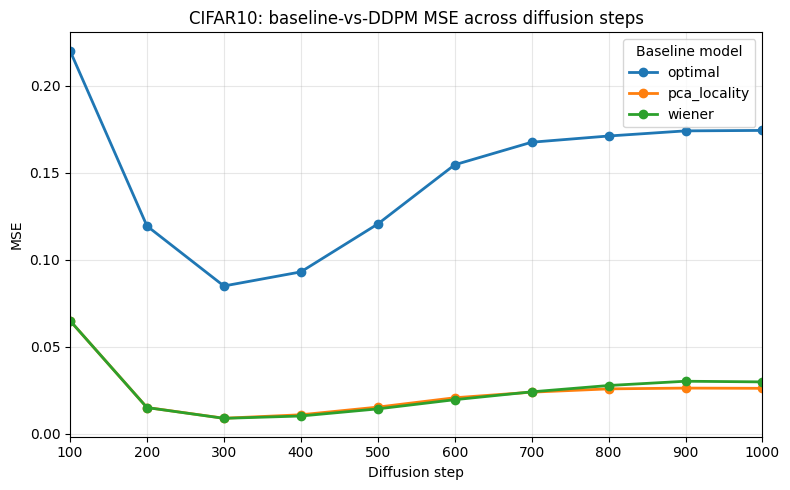

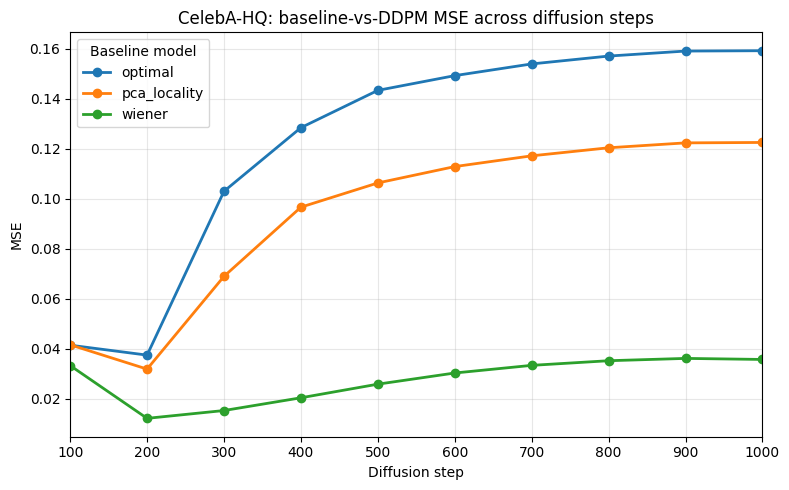

In [11]:
model_prefixes = ["optimal", "pca_locality", "wiener"]
dataset_filters = {"cifar10": "CIFAR10", "celeba": "CelebA-HQ"}

def infer_model_name(run_name):
    for prefix in model_prefixes:
        if run_name.startswith(prefix):
            return prefix
    return None

def plot_mse_trajectories(dataset_key, title):
    subset = df_summary_steps[df_summary_steps["run_name"].str.contains(dataset_key, case=False, na=False)].copy()
    subset["model"] = subset["run_name"].apply(infer_model_name)
    subset = subset.dropna(subset=["model"])

    trajectory = (
        subset.groupby(["model", "diffusion_step"], as_index=False)["mse_score_vs_unet"]
        .mean()
        .sort_values(["model", "diffusion_step"], ascending=[True, True])
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    for model_name in model_prefixes:
        model_data = trajectory[trajectory["model"] == model_name]
        if model_data.empty:
            continue
        ax.plot(
            model_data["diffusion_step"],
            model_data["mse_score_vs_unet"],
            marker="o",
            linewidth=2,
            label=model_name,
        )

    ax.set_title(title)
    ax.set_xlabel("Diffusion step")
    ax.set_ylabel("MSE")
    ax.set_xlim(100, 1000)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Baseline model")
    plt.tight_layout()
    plt.show()

for dataset_key, title in dataset_filters.items():
    plot_mse_trajectories(dataset_key, f"{title}: baseline-vs-DDPM MSE across diffusion steps")

---
## 6  Qualitative Results - Comparison Images

Each image contains two rows:

- **Row 1**: The analytical model's prediction.
- **Row 2**: The pretrained UNet's prediction.

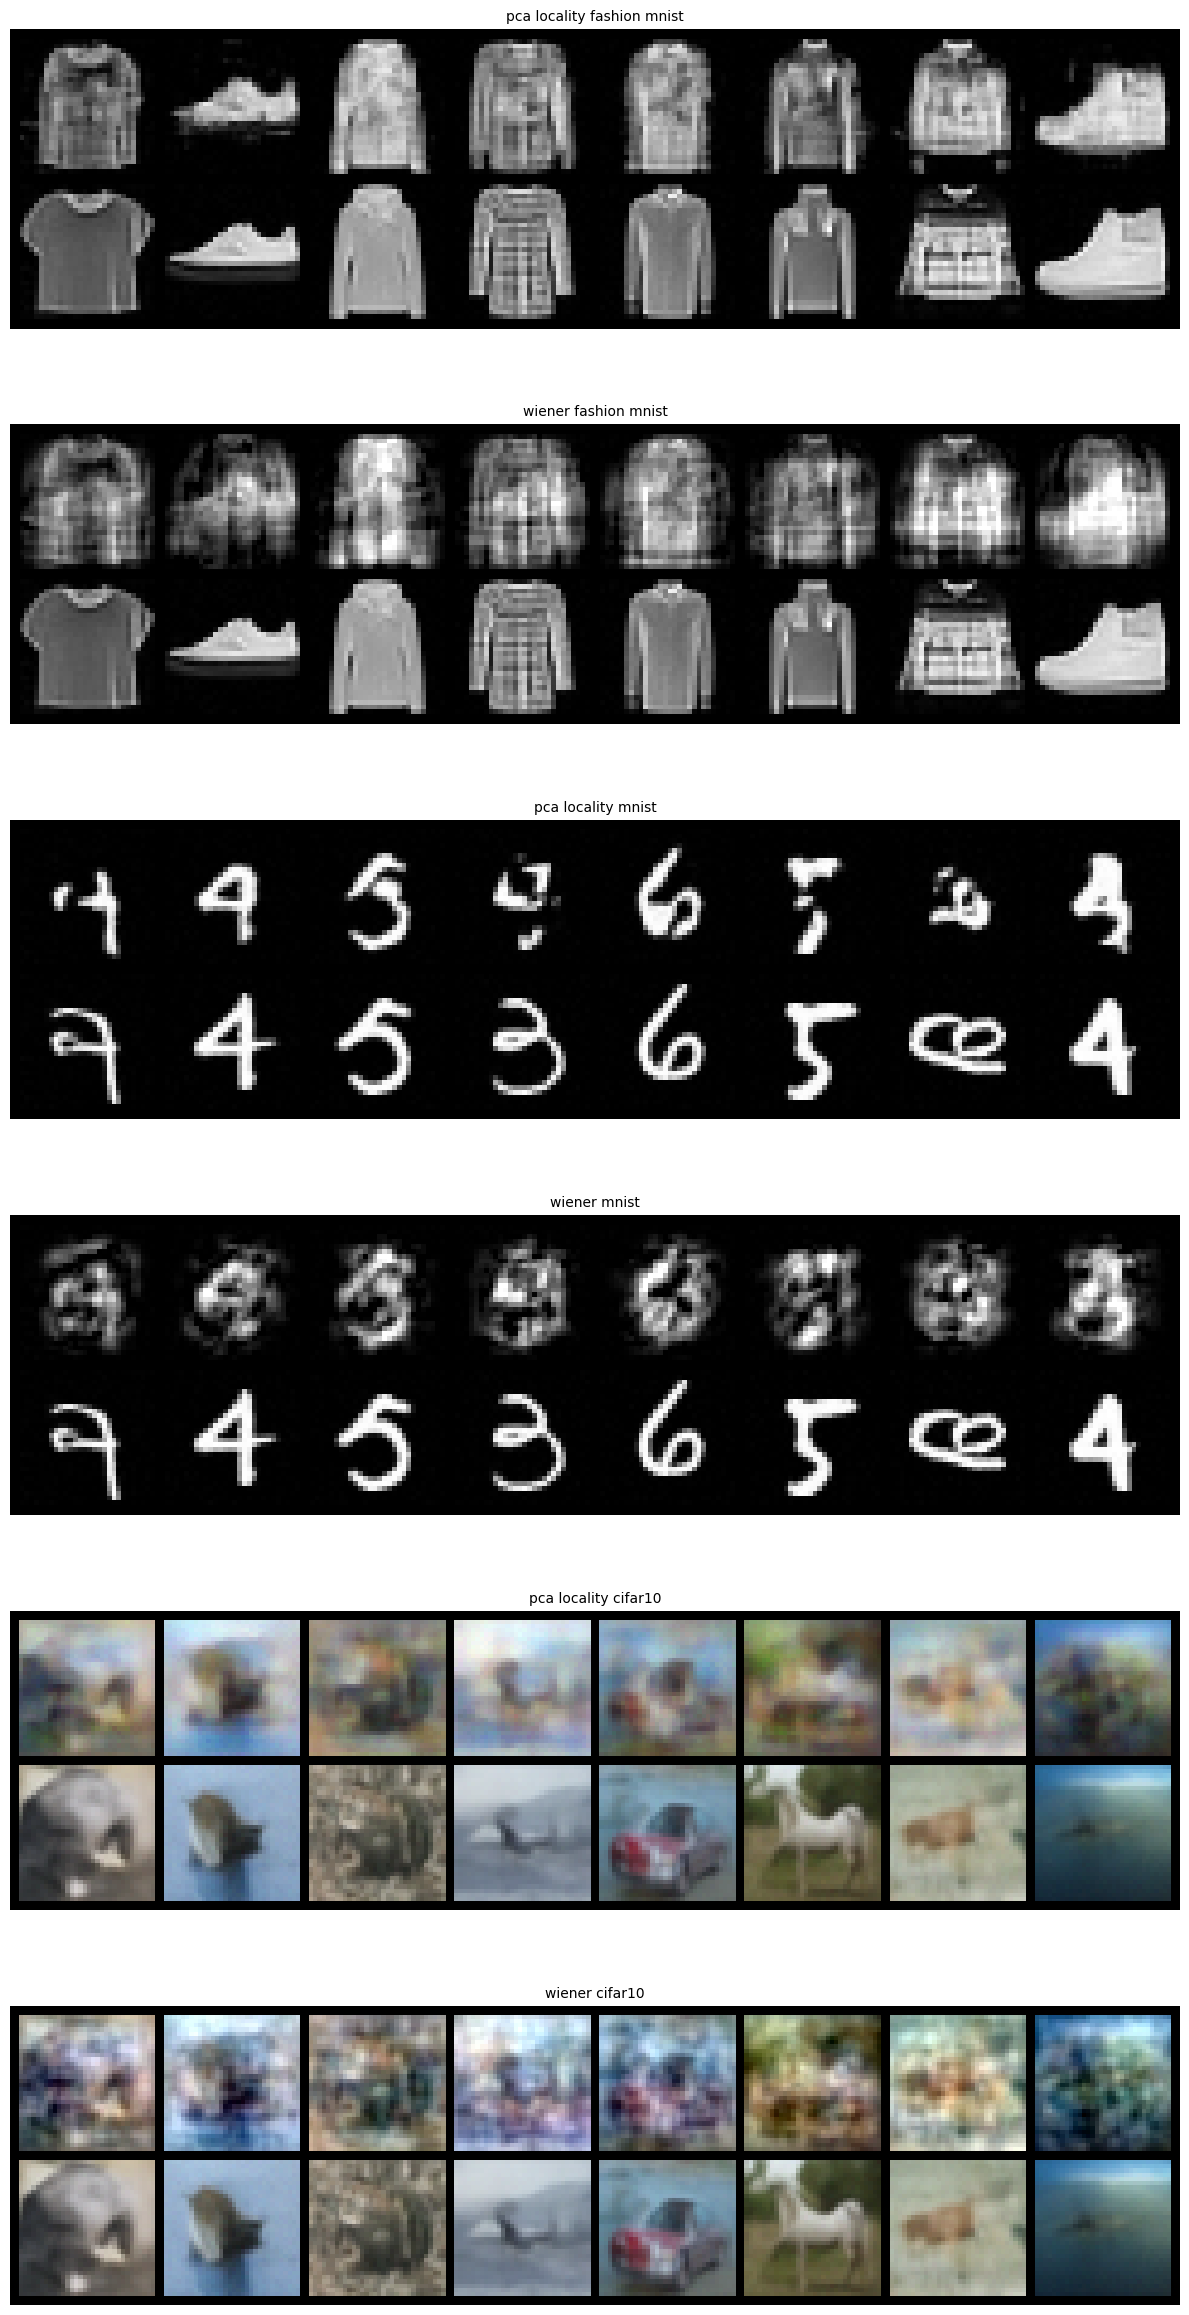

In [19]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import re

selected_images = [
    project_root / "data" / "runs" / "default" / "pca_locality_fashion_mnist_20260527-140534" / "comparison" / "step_0000_comparison_xt.png",
    project_root / "data" / "runs" / "default" / "wiener_fashion_mnist_20260527-142601" / "comparison" / "step_0000_comparison_xt.png",
    project_root / "data" / "runs" / "default" / "pca_locality_mnist_20260526-132456" / "comparison" / "step_0000_comparison_xt.png",
    project_root / "data" / "runs" / "default" / "wiener_mnist_20260527-142713" / "comparison" / "step_0000_comparison_xt.png",
    project_root / "data" / "runs" / "default" / "pca_locality_cifar10_20260526-194150" / "comparison" / "step_0000_comparison_xt.png",
    project_root / "data" / "runs" / "default" / "wiener_cifar10_20260527-142504" / "comparison" / "step_0000_comparison_xt.png",
]

selected_images = [image_path for image_path in selected_images if image_path.exists()]
rows = len(selected_images)
fig, axes = plt.subplots(rows, 1, figsize=(12, 4 * rows))
axes = [axes] if rows == 1 else list(axes)

for axis, image_path in zip(axes, selected_images):
    image = Image.open(image_path)
    axis.imshow(image)
    title = image_path.parent.parent.name
    title = re.sub(r"(_job\d+_task\d+|_\d{8}-\d{6})$", "", title)
    axis.set_title(title.replace("_", " "), fontsize=10)
    axis.axis("off")

plt.tight_layout()
plt.show()